In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings; warnings.filterwarnings('ignore')
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline

data_raw = pd.read_csv("ScrapeData/divar_clean.csv")
data_raw.head()

,token,url,title,price,mileage,year,color,brand_model,gearbox,fuel,insurance,score_engine,score_chassis,score_body,score_gearbox,desc
0,Qa53qGdd,https://divar.ir/v/Qa53qGdd,زنگ خطرهای قبل از معامله,"‏۱,۳۰۰,۰۰۰,۰۰۰ تومان",۰,۱۴۰۴ - ۲۰۲۵,آبی,زامیاد Z 24 دوگانه سوز آپشنال,دنده‌ای,دوگانه‌سوز شرکتی,۱۲ ماه,سالم,سالم و پلمپ,سالم و بی‌خط و خش,سالم و پلمپ,⭐️مبلغ درج شده در آگهی پیش پرداخت خرید اقساطی ...
1,gaZ4Elay,https://divar.ir/v/gaZ4Elay,زنگ خطرهای قبل از معامله,"‏۱,۷۴۵,۰۰۰,۰۰۰ تومان",۰,۱۴۰۵ - ۲۰۲۶,سفید,رانا پلاس TU5P,دنده‌ای,بنزین,۱۲ ماه,سالم,سالم و پلمپ,سالم و بی‌خط و خش,سالم و پلمپ,رانا پلاس فول1405/3/20\nآگهی شخص\nبرگ سبز،سندک...
2,ga18JNlI,https://divar.ir/v/ga18JNlI,زنگ خطرهای قبل از معامله,"‏۲,۰۵۰,۰۰۰,۰۰۰ تومان",۲۱۰۰۰۰,۲۰۰۸,سفید,هیوندای FX کوپه اتوماتیک,اتوماتیک,بنزین,۷ ماه,تعویض شده,سالم و پلمپ,دوررنگ,سالم و پلمپ,فروش هیوندا کوپه fx زیر قیمت \nشاسی ها سالم و ...
3,ga1AadsJ,https://divar.ir/v/ga1AadsJ,زنگ خطرهای قبل از معامله,"‏۷,۵۰۰,۰۰۰,۰۰۰ تومان",۲۸۸۰۰۰,۱۳۸۳ - ۲۰۰۴,نقره‌ای,پژو پارس ساده,دنده‌ای,بنزین,۳ ماه,سالم,سالم و پلمپ,صافکاری بی‌رنگ,سالم و پلمپ,مدل ۸۳ فرانسه استثنایی بدون رنگ نقره ایی جلو ع...
4,ga1Aaf9e,https://divar.ir/v/ga1Aaf9e,زنگ خطرهای قبل از معامله,"‏۷۷۵,۰۰۰,۰۰۰ تومان",۱۲۲۰۰۰,۱۳۹۸ - ۲۰۱۹,سفید,ساینا دنده‌ای EX,دنده‌ای,بنزین,۱۲ ماه,سالم,سالم و پلمپ,رنگ‌شدگی در ۲ ناحیه,سالم و پلمپ,"با سلام؛\nساینا EX \nمدل ۱۳۹۸\nکارکرد: ۱۲۲,۰۰۰..."


In [2]:
from utils import clean_price, drop_col, color_transition, gearbox_transition,\
fuel_transition, score_engine_transition, score_chassis_transition, score_body_transition, score_gearbox_transition, split_year

df = drop_col(data_raw)
df['price'] = df['price'].apply(clean_price)
df['mileage'] = df['mileage'].apply(clean_price)
df[['Date_jalali', 'date_miladi']] = df['year'].apply(split_year)
df['Date_jalali'] = df['Date_jalali']
df['date_miladi'] = df['date_miladi']
df.drop(columns='year', inplace=True)
df = color_transition(df)  
df = gearbox_transition(df)
df = fuel_transition(df)
df["insurance"] = df['insurance'].apply(clean_price)
df = score_engine_transition(df)
df = score_chassis_transition(df)
df = score_body_transition(df)
df = score_gearbox_transition(df)
df.drop(columns='score_body_region_count', inplace=True)

In [3]:
# df.to_csv('divar_final_en.csv', index=False)
df = pd.read_csv("Data/divar_final_en.csv")
print(df.shape[0], 'x', df.shape[1])
df.head()

5009 x 13


,url,price,mileage,color,gearbox,fuel,insurance,score_engine,score_chassis,score_body,score_gearbox,Date_jalali,date_miladi
0,https://divar.ir/v/Qa53qGdd,1300000000,0,Blue,Manual,Bi-fuel (Factory),12.0000,Healthy,Healthy & Sealed,"Healthy, No Scratches",Healthy & Sealed,1404.0000,2025
1,https://divar.ir/v/gaZ4Elay,1745000000,0,White,Manual,Gasoline,12.0000,Healthy,Healthy & Sealed,"Healthy, No Scratches",Healthy & Sealed,1405.0000,2026
2,https://divar.ir/v/ga18JNlI,2050000000,210000,White,Automatic,Gasoline,7.0000,Replaced,Healthy & Sealed,Two-tone (Repainted),Healthy & Sealed,NaN,2008
3,https://divar.ir/v/ga1AadsJ,7500000000,288000,Silver,Manual,Gasoline,3.0000,Healthy,Healthy & Sealed,"Bodywork, No Paint",Healthy & Sealed,1383.0000,2004
4,https://divar.ir/v/ga1Aaf9e,775000000,122000,White,Manual,Gasoline,12.0000,Healthy,Healthy & Sealed,Repainted in 2 area(s),Healthy & Sealed,1398.0000,2019


In [4]:
df['car_age'] = 2026 - df['date_miladi'] 
df['car_age'] = df['car_age'].astype(int)

In [18]:
df.rename(columns={'insurance' : 'insurance_duration'})

,url,price,mileage,color,gearbox,fuel,insurance_duration,score_body,car_age
0,https://divar.ir/v/Qa53qGdd,1300000000.0000,0,Blue,Manual,Bi-fuel (Factory),12.0000,"Healthy, No Scratches",1
1,https://divar.ir/v/gaZ4Elay,1745000000.0000,0,White,Manual,Gasoline,12.0000,"Healthy, No Scratches",0
2,https://divar.ir/v/ga18JNlI,2050000000.0000,210000,White,Automatic,Gasoline,7.0000,Two-tone (Repainted),18
3,https://divar.ir/v/ga1AadsJ,7500000000.0000,288000,Silver,Manual,Gasoline,3.0000,"Bodywork, No Paint",22
4,https://divar.ir/v/ga1Aaf9e,775000000.0000,122000,White,Manual,Gasoline,12.0000,Repainted in 2 area(s),7
...,...,...,...,...,...,...,...,...,...
5004,https://divar.ir/v/Qa1b8xh0,1000.0000,100000,Blue,Automatic,Gasoline,7.0000,Minor Scratches,8
5005,https://divar.ir/v/gaUkKTyp,1550000000.0000,115000,White,Automatic,Gasoline,10.0000,"Bodywork, No Paint",10
5006,https://divar.ir/v/ga0IDcdc,685000000.0000,250000,Gray,Manual,Bi-fuel (Factory),3.0000,Fully Repainted,14
5007,https://divar.ir/v/gawY0lk-,4400000000.0000,12,White,Automatic,Gasoline,1.0000,"Healthy, No Scratches",8


In [5]:
df = df.rename(columns={'insurance' : 'insurance_duration'})

In [6]:
df.columns = df.columns.str.lower()

In [7]:
df.drop(columns=['date_jalali', 'date_miladi', 'score_engine', 'score_chassis', 'score_gearbox'], inplace=True)

In [8]:
valid_body = df['score_body'].value_counts()[lambda x: x > 99].index
valid_fuels = df['fuel'].value_counts()[lambda x: x > 51].index
valid_colors = df['color'].value_counts()[lambda x: x > 33].index

df_filtered = df[
    df['score_body'].isin(valid_body) &
    df['fuel'].isin(valid_fuels) &
    df['color'].isin(valid_colors)
]

## ****Dataset Overview****

In [9]:
print('Shape Data:', df.shape)
print('\nDtypes:')
df.dtypes.value_counts()

Shape Data: (5009, 9)

Dtypes:


str        5
int64      3
float64    1
Name: count, dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   url                 5009 non-null   str    
 1   price               5009 non-null   int64  
 2   mileage             5009 non-null   int64  
 3   color               5009 non-null   str    
 4   gearbox             4720 non-null   str    
 5   fuel                5009 non-null   str    
 6   insurance_duration  4271 non-null   float64
 7   score_body          5009 non-null   str    
 8   car_age             5009 non-null   int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 352.3 KB


In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
url,5009,5009,https://divar.ir/v/Qa53qGdd,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,5009.0000,NaN,NaN,NaN,259487707592.5334,15797062928280.6934,1000.0000,715000000.0000,1250000000.0000,2390000000.0000,1111100000000000.0000
mileage,5009.0000,NaN,NaN,NaN,134866.9782,130579.1409,0.0000,25000.0000,100000.0000,218000.0000,1000000.0000
color,5009,36,White,2739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gearbox,4720,2,Manual,3111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel,5009,7,Gasoline,4591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_duration,4271.0000,NaN,NaN,NaN,7.9527,3.1532,1.0000,6.0000,8.0000,11.0000,12.0000
score_body,5009,15,"Healthy, No Scratches",2987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_age,5009.0000,NaN,NaN,NaN,8.9788,7.1913,0.0000,3.0000,8.0000,14.0000,39.0000


In [12]:
print("Duplicates:", df.duplicated().sum())
print("Memory (MB)", round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicates: 0
Memory (MB) 1.64


In [13]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing':missing, 'Percent':missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing',ascending=False)
missing_df

,Missing,Percent
insurance_duration,738,14.7335
gearbox,289,5.7696


In [14]:
df.loc[df['price'] == 1_000_000, 'price'] = np.nan
print("Missing price before:", df['price'].isna().sum())    

Missing price before: 14


In [15]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing':missing, 'Percent':missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing',ascending=False)
missing_df

,Missing,Percent
insurance_duration,738,14.7335
gearbox,289,5.7696
price,14,0.2795


In [16]:
from utils import handle_missing
df = handle_missing(df)
df.isna().sum()

url                   0
price                 0
mileage               0
color                 0
gearbox               0
fuel                  0
insurance_duration    0
score_body            0
car_age               0
dtype: int64

In [17]:
df['insurance'] = df['insurance'].astype(int)

KeyError: 'insurance'

##  ****Detecting mixed types****

In [ ]:
from utils import detect_mixed_types
detect_mixed_types(df)

{}

## ****Detect Outliers****

In [ ]:
df_model = df.copy()

In [ ]:
valid = df_model['price'].dropna()
valid = valid[valid > 0]
log_vals = np.log1p(valid)
Q1, Q3 = log_vals.quantile(0.25), log_vals.quantile(0.75)
IQR = Q3 - Q1

mod_lower_log, mod_upper_log = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
ext_lower_log, ext_upper_log = Q1 - 3.0 * IQR, Q3 + 3.0 * IQR

mod_lower, mod_upper = np.expm1(mod_lower_log), np.expm1(mod_upper_log)
ext_lower, ext_upper = max(np.expm1(ext_lower_log), 0), np.expm1(ext_upper_log)

print(f"mild bound: [{mod_lower:,.0f} , {mod_upper:,.0f}]")
print(f"extreme bound: [{ext_lower:,.0f} , {ext_upper:,.0f}]")

mild bound: [118,308,072 , 14,605,934,851]
extreme bound: [19,439,999 , 88,888,888,666]


In [ ]:
mask_mod_low = df_model['price'] < mod_lower
mask_mod_high = df_model['price'] > mod_upper
print(f"{mask_mod_low.sum() + mask_mod_high.sum()} mild rows -> Capped")
df_model.loc[mask_mod_low, 'price'] = mod_lower
df_model.loc[mask_mod_high, 'price'] = mod_upper

313 mild rows -> Capped


In [ ]:
features = df_model[['price','fuel', 'mileage', 'gearbox']].copy()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
features[['fuel_enc', 'gearbox_enc']] = enc.fit_transform(
    features[['fuel', 'gearbox']].astype(str)
)

knn_input = features[['price', 'mileage', 'fuel_enc', 'gearbox_enc']].copy()
knn_input['price'] = np.log1p(knn_input['price'])
knn_input['mileage'] = np.log1p(knn_input['mileage'])

means, stds = knn_input.mean(), knn_input.std()
knn_input_scaled = (knn_input - means) / stds

imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_scaled = imputer.fit_transform(knn_input_scaled)
imputed = imputed_scaled * stds.values + means.values

df_model['price'] = np.expm1(imputed[:, 0])

print("\nprice:", df_model['price'].isna().sum())
print(df_model['price'].describe().round(0))


price: 0
count          4995.0000
mean     2118781569.0000
std      2537628932.0000
min       118308072.0000
25%       720000000.0000
50%      1250000000.0000
75%      2400000000.0000
max     14605934851.0000
Name: price, dtype: float64


In [ ]:
from utils import detect_outliers
detect_outliers(df_model)

price                --->   479 outliers (9.59%)
bounds: [-1,800,000,000.00 , 4,920,000,000.00]
lowest: [4929999999.999996, 4949999999.999992, 4949999999.999992, 4949999999.999992, 4949999999.999992, 4949999999.999992, 4969999999.999994, 4979999999.999992, 4979999999.999992, 4979999999.999992]
highest: [14605934850.589937, 14605934850.589937, 14605934850.589937, 14605934850.589937, 14605934850.589937, 14605934850.589937, 14605934850.589937, 14605934850.589937, 14605934850.589937, 14605934850.589937]

mileage              --->    39 outliers (0.78%)
bounds: [-264,500.00 , 507,500.00]
lowest: [510000, 520000, 520000, 520000, 527000, 530000, 538000, 540000, 543326, 550000]
highest: [700000, 700000, 740000, 875578, 880000, 1000000, 1000000, 1000000, 1000000, 1000000]

insurance            --->     0 outliers (0.00%)
bounds: [0.00 , 16.00]

car_age              --->    26 outliers (0.52%)
bounds: [-13.50 , 30.50]
lowest: [31, 31, 31, 31, 32, 32, 32, 32, 32, 32]
highest: [34, 34, 34, 34, 34,

In [ ]:
df.nlargest(20, 'price')[
    ['price','car_age','mileage','gearbox','fuel']
]

,price,car_age,mileage,gearbox,fuel
535,1111100000000000.0000,10,68000,Automatic,Gasoline
2538,123456600000000.0000,12,200000,Manual,Gasoline
4560,10000000000000.0000,8,53000,Manual,Bi-fuel (Factory)
4700,8300000000000.0000,1,0,Automatic,Gasoline
3280,4900000000000.0000,2,20776,Manual,Gasoline
710,4300000000000.0000,8,30000,Automatic,Gasoline
1089,4050000000000.0000,2,32000,Manual,Gasoline
4870,3960000000000.0000,21,270000,Automatic,Gasoline
3310,3650000000000.0000,0,0,Manual,Gasoline
3497,2740000000000.0000,9,15000,Automatic,Gasoline


In [ ]:
df.nsmallest(20, 'price')[
    ['price','car_age','mileage','gearbox','fuel']
]

,price,car_age,mileage,gearbox,fuel
34,1000.0000,11,178000,Automatic,Gasoline
57,1000.0000,2,0,Manual,Gasoline
64,1000.0000,0,0,Manual,Gasoline
111,1000.0000,3,113000,Automatic,Gasoline
136,1000.0000,19,178000,Automatic,Gasoline
207,1000.0000,0,0,Automatic,Gasoline
315,1000.0000,2,0,Automatic,Gasoline
371,1000.0000,21,158,Manual,Gasoline
397,1000.0000,33,235000,Manual,Gasoline
545,1000.0000,6,330000,Manual,Gasoline


## **to have better sight at price**

In [ ]:
df2 = df.copy()
df2['price'] = df2['price'].astype(str)
df2.loc[:, "price"] = df["price"].map('{:,.0f}'.format)
df2['price'].sample(30).to_frame()

,price
1085,"400,000,000"
4906,"1,980,000,000"
2656,"1,250,000,000"
2713,"5,350,000,000"
2219,"1,000"
4229,"1,420,000,000"
3610,"920,000,000"
4160,"928,000,000"
1146,"1,150,000,000"
1336,"100,000"


##  ****Target Variable Distribution****

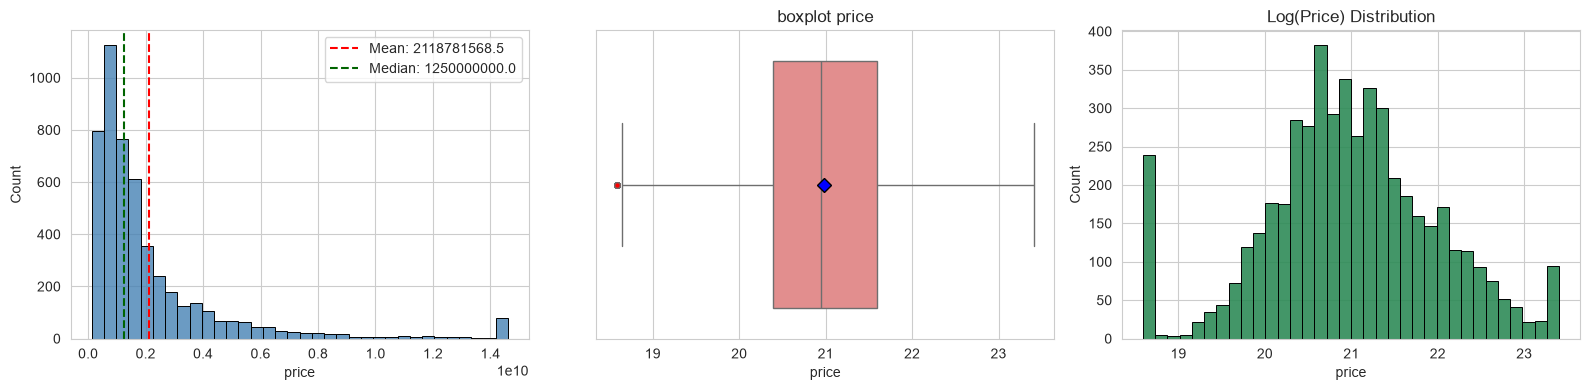

skewness: 2.93
kurtosis: 9.96
variance: 6439560594468417536.00
count          4995.0000
mean     2118781568.5431
std      2537628931.5951
min       118308071.7580
25%       720000000.0000
50%      1250000000.0000
75%      2400000000.0000
max     14605934850.5899
Name: price, dtype: float64


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=df_model, x="price", color="steelblue", edgecolor="black", alpha=0.8, bins=int(2*len(df_model)**(1/3)), ax=ax[0])
ax[0].axvline(np.mean(df_model["price"]), color='red', linestyle='--', label=f"Mean: {df_model['price'].mean():.1f}")
ax[0].axvline(df_model["price"].median(), color="darkgreen", linestyle="--", label=f"Median: {df_model['price'].median():.1f}")
ax[0].legend()
sns.boxplot(x=np.log(df_model["price"]), color='lightcoral', ax=ax[1], showmeans=True,
    meanprops={
        'marker': 'D',
        'markerfacecolor': 'blue',
        'markeredgecolor': 'black',
        'markersize': 7
    },
    flierprops={
        'marker': 'o',
        'markersize': 4,
        'markerfacecolor': 'red',
        'alpha': 0.6
    }
)
ax[2].set_title("Log(Price) Distribution")
sns.histplot(data=np.log(df_model["price"]), color="seagreen", edgecolor="black", alpha=0.9, bins=int(2*len(df_model)**(1/3)), ax=ax[2])
ax[1].set_title("boxplot price")
plt.tight_layout(); plt.show()
print(f"skewness: {df_model['price'].skew():.2f}")
print(f"kurtosis: {df_model['price'].kurtosis():.2f}")
print(f"variance: {df_model['price'].var():.2f}")
print(df_model.price.describe())

## ****Univariate Analysis — Numeric Features****

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'price' in numeric_cols:
    numeric_cols.remove('price')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols)

Numeric features (3):
['mileage', 'insurance', 'car_age']


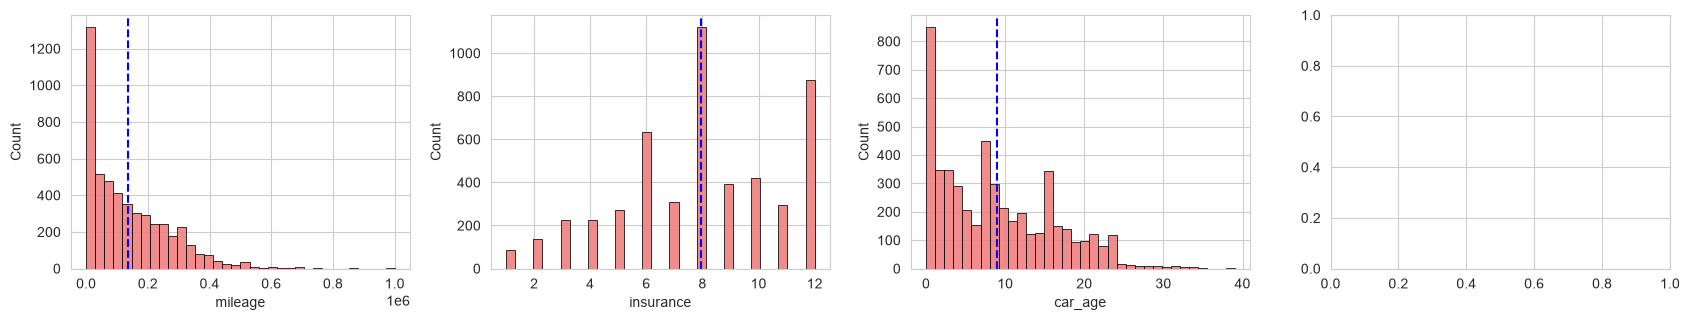

In [ ]:
import math
n_show = min(len(df_model), 4)
ncols = 4
nrows = math.floor(n_show / ncols)
fig, ax = plt.subplots(nrows, ncols, figsize=(17, 3.3 * nrows))
ax = np.array(ax).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    sns.histplot(ax=ax[i], data=df_model[col], color='lightcoral', edgecolor='black', bins=int(2*len(df_model)**(1/3)), alpha=0.9)
    ax[i].axvline(np.mean(df_model[col]), color='b', linestyle='--')
plt.tight_layout(); plt.show()

## ****Univariate Analysis — Categorical Features****

In [ ]:
categorical_cols = df_filtered .select_dtypes(['object', 'str']).columns.tolist()
if 'url' in categorical_cols:
    categorical_cols.remove('url')
print(f'Categorical features ({len(categorical_cols)}):')
print(categorical_cols)

Categorical features (4):
['color', 'gearbox', 'fuel', 'score_body']


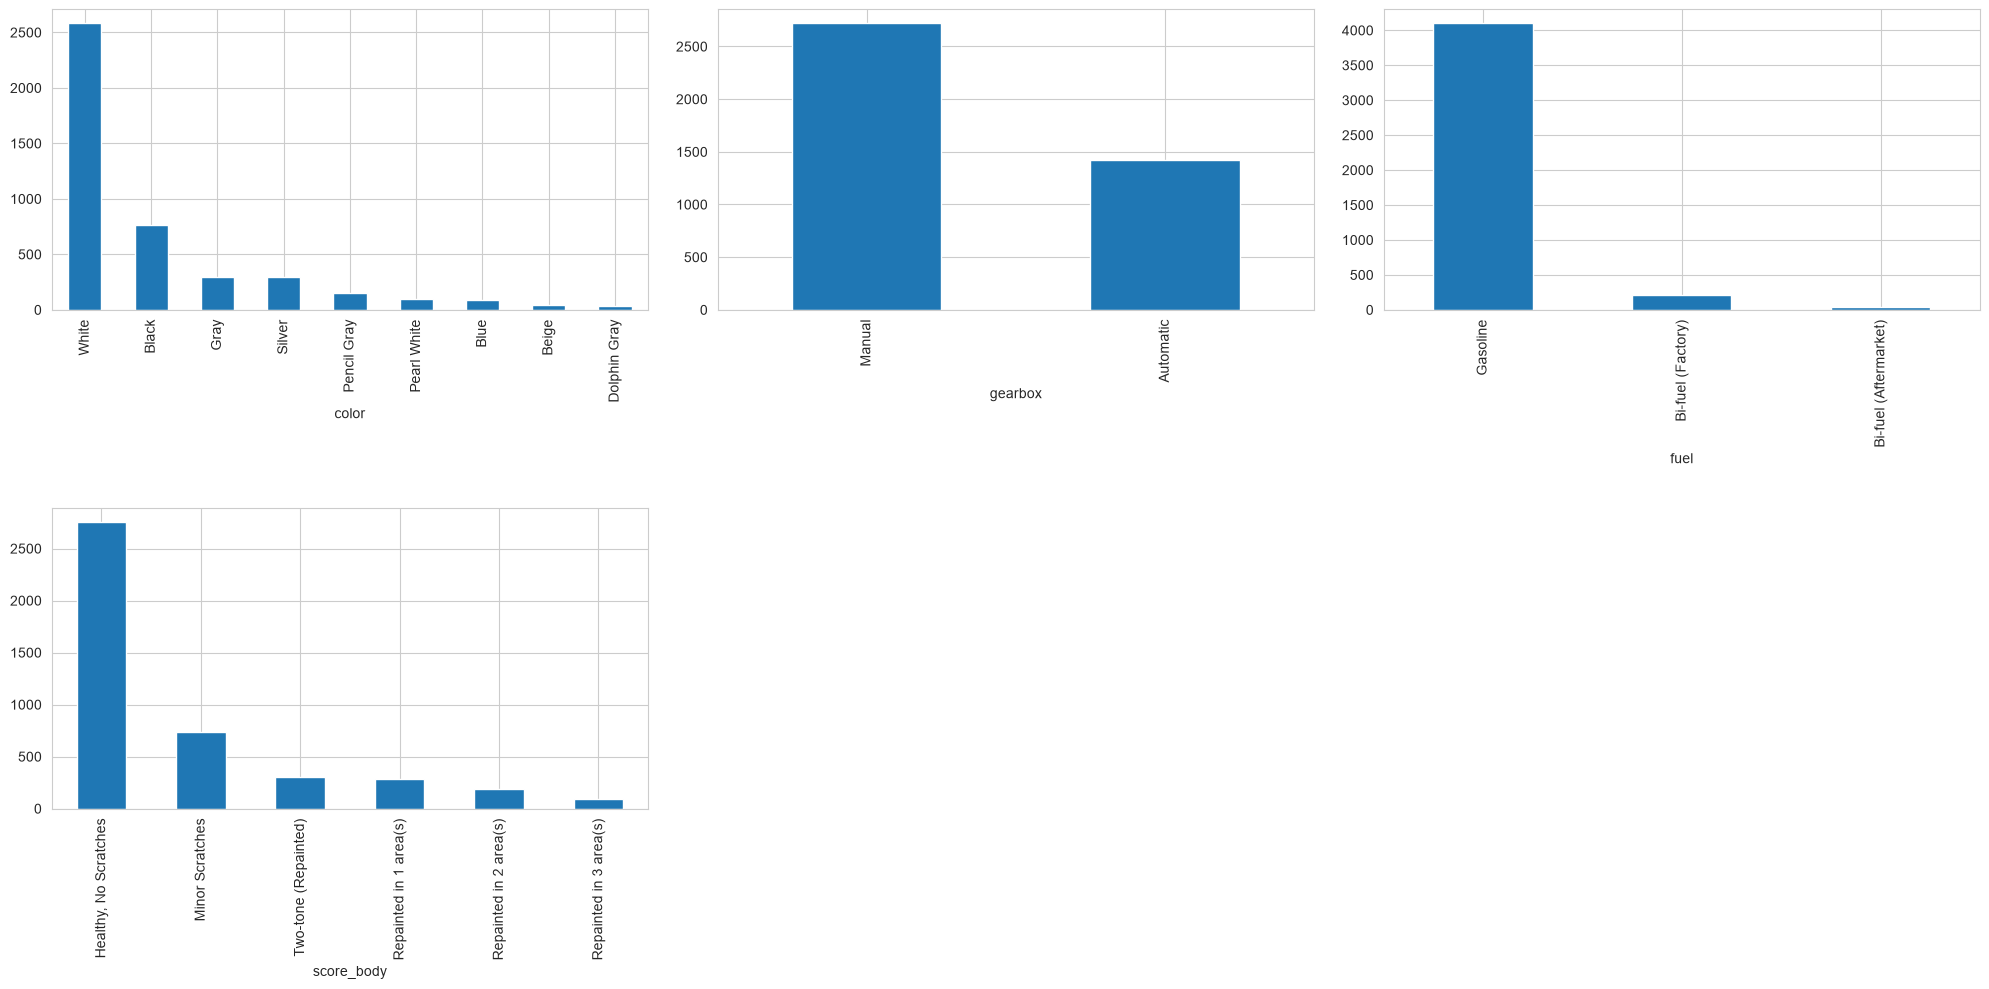

In [ ]:
import math
n_show = min(len(categorical_cols), 7)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, ax = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
ax = np.array(ax).reshape(-1)
for i, col in enumerate(categorical_cols[:n_show]):
    df_filtered [col].value_counts().plot(kind='bar', ax=ax[i])
for j in range(n_show, len(ax)):
    ax[j].axis('off')
plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

## ****Bivariate Analysis — Features vs Target****

In [ ]:
corrs_all = df_model[numeric_cols + ['price']].corr()['price'].sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'price'][:6]
print("Top features by (correlation) with target:")
print(corrs_all[top_features].round(3) * 100) 

Top features by (correlation) with target:
insurance    10.8000
car_age     -28.9000
mileage     -31.6000
Name: price, dtype: float64


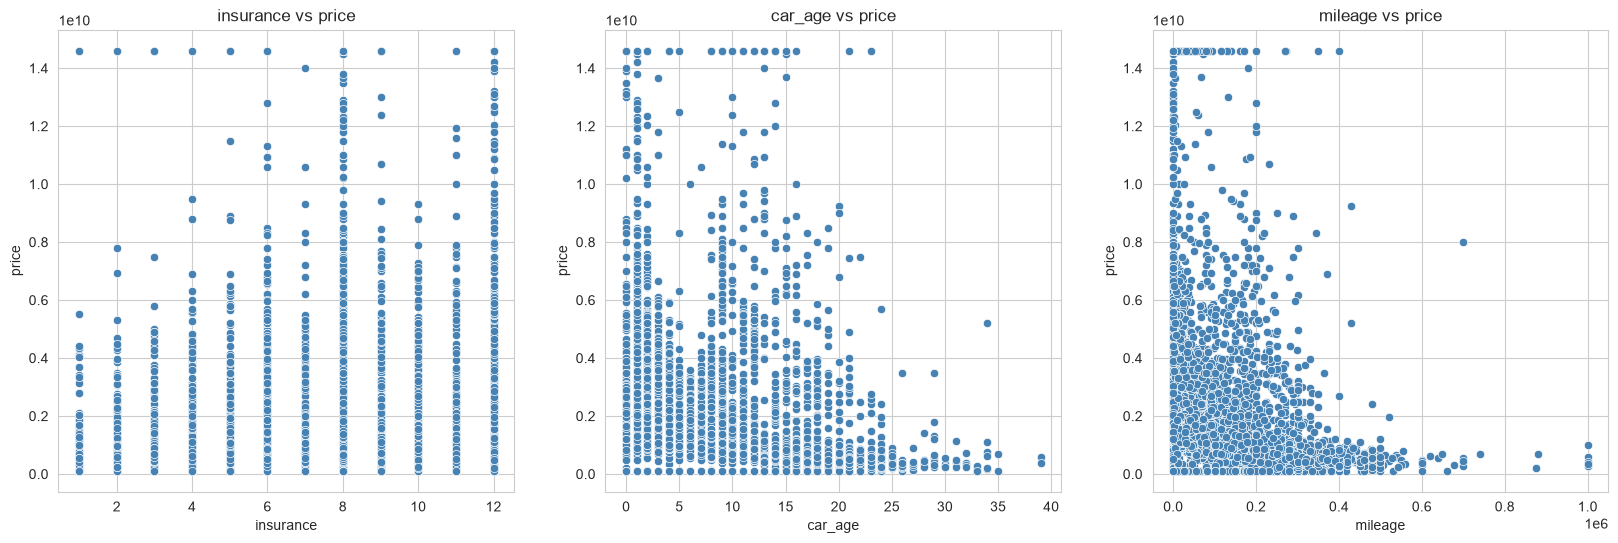

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
ax = ax.flatten()
for i, col in enumerate(top_features[:6]):
    sns.scatterplot(ax=ax[i], data=df_model, x=col, y='price', alpha=1, color='steelblue')
    ax[i].set_xlabel(col); ax[i].set_ylabel('price')
    ax[i].set_title(f'{col} vs price')
for j in range(n_show, len(ax)):
    ax[j].axis('off')

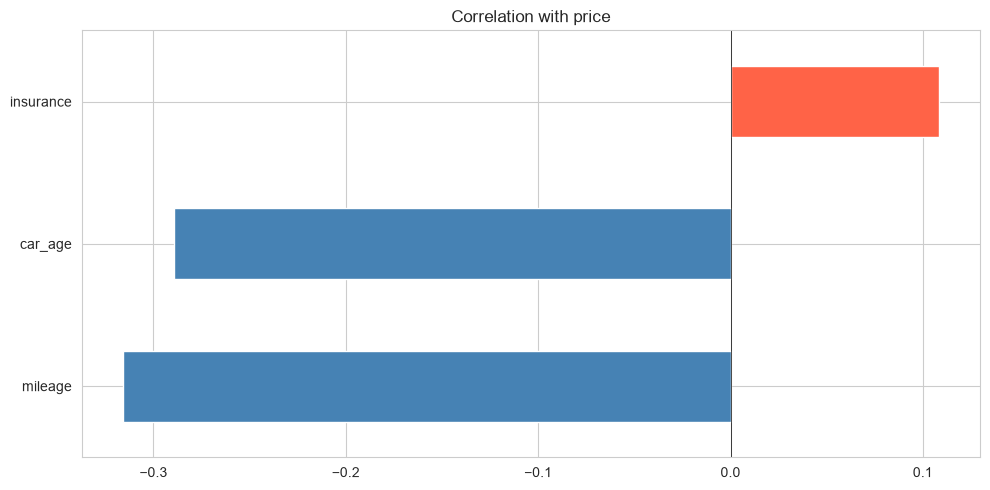

In [ ]:
target_corr = df_model[numeric_cols + ['price']].corr()['price'].drop('price').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with price')
plt.axvline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

In [ ]:
df_model.groupby('car_age')['price'].median().sort_values(ascending=False)

car_age
1    2487500000.0000
2    2100000000.0000
0    1930000000.0000
3    1750000000.0000
4    1600000000.0000
8    1485000000.0000
9    1420000000.0000
5    1397500000.0000
6    1320000000.0000
10   1225000000.0000
7    1192500000.0000
11   1167500000.0000
12    982500000.0000
13    870000000.0000
14    825000000.0000
15    794500000.0000
16    760000000.0000
18    690000000.0000
34    685000000.0000
17    650000000.0000
19    613000000.0000
29    610000000.0000
20    596500000.0000
22    515000000.0000
21    502500000.0000
39    483000000.0000
24    460000000.0000
31    457500000.0000
23    445000000.0000
35    409154035.8790
27    395000000.0000
28    365000000.0000
32    335000000.0000
25    305000000.0000
30    302500000.0000
26    300000000.0000
33    145000000.0000
Name: price, dtype: float64

In [ ]:
df_model.groupby("fuel")["price"].median().sort_values(ascending=False)

fuel
Plug-in Hybrid          10850000000.0000
Electric                 6775000000.0000
Hybrid                   6475000000.0000
Diesel                   2280000000.0000
Gasoline                 1298000000.0000
Bi-fuel (Factory)         700000000.0000
Bi-fuel (Aftermarket)     432500000.0000
Name: price, dtype: float64

In [ ]:
df_model.groupby('gearbox')['price'].median()

gearbox
Automatic   2955000000.0000
Manual       930000000.0000
Name: price, dtype: float64

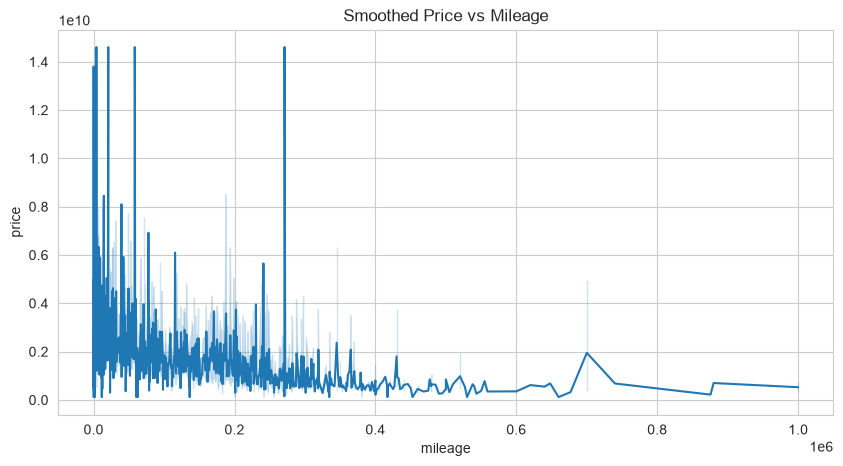

In [ ]:
df_sorted = df_model.sort_values("mileage")
plt.figure(figsize=(10,5))
sns.lineplot(data=df_sorted, x="mileage", y="price")
plt.title("Smoothed Price vs Mileage")
plt.show()

In [ ]:
df["mileage_q"] = pd.qcut(df["mileage"], q=5, duplicates="drop")

df.groupby("mileage_q")["price"].agg(count='count', median='median', mean='mean')   

,count,median,mean
mileage_q,,,
"(-0.001, 13000.0]",1005,2170000000.0000,20056953491.5423
"(13000.0, 68956.0]",993,1800000000.0000,1149080509984.8943
"(68956.0, 140000.0]",1018,1380000000.0000,4823979940.0786
"(140000.0, 246200.0]",980,975000000.0000,129907032864.2857
"(246200.0, 1000000.0]",999,590000000.0000,6366391262.2623


In [ ]:
from scipy.stats import spearmanr

corr, p = spearmanr(df["mileage"], df["price"])
print(corr)

-0.5005355228294441


In [ ]:
df[['price','mileage','car_age']].corr(method='spearman')

,price,mileage,car_age
price,1.0000,-0.5005,-0.5010
mileage,-0.5005,1.0000,0.8658
car_age,-0.5010,0.8658,1.0000


In [ ]:
df.groupby(pd.qcut(df['car_age'], 5))['price'].median()

car_age
(-0.001, 2.0]   2180000000.0000
(2.0, 5.0]      1610000000.0000
(5.0, 10.0]     1310000000.0000
(10.0, 16.0]     890000000.0000
(16.0, 39.0]     530000000.0000
Name: price, dtype: float64

In [ ]:
pivot = pd.pivot_table(df, values='price', index=pd.qcut(df['car_age'],5), columns=pd.qcut(df['mileage'],5), aggfunc='median')
pivot

mileage,"(-0.001, 13000.0]","(13000.0, 68956.0]","(68956.0, 140000.0]","(140000.0, 246200.0]","(246200.0, 1000000.0]"
car_age,,,,,
"(-0.001, 2.0]",2334000000.0000,2035000000.0000,1020000000.0000,NaN,1000000000.0000
"(2.0, 5.0]",1677500000.0000,1700000000.0000,1505000000.0000,955000000.0000,827500000.0000
"(5.0, 10.0]",1550000000.0000,1749000000.0000,1395000000.0000,1170000000.0000,785000000.0000
"(10.0, 16.0]",940000000.0000,2000000000.0000,1180000000.0000,982500000.0000,700000000.0000
"(16.0, 39.0]",422500000.0000,555000000.0000,560000000.0000,657500000.0000,500000000.0000


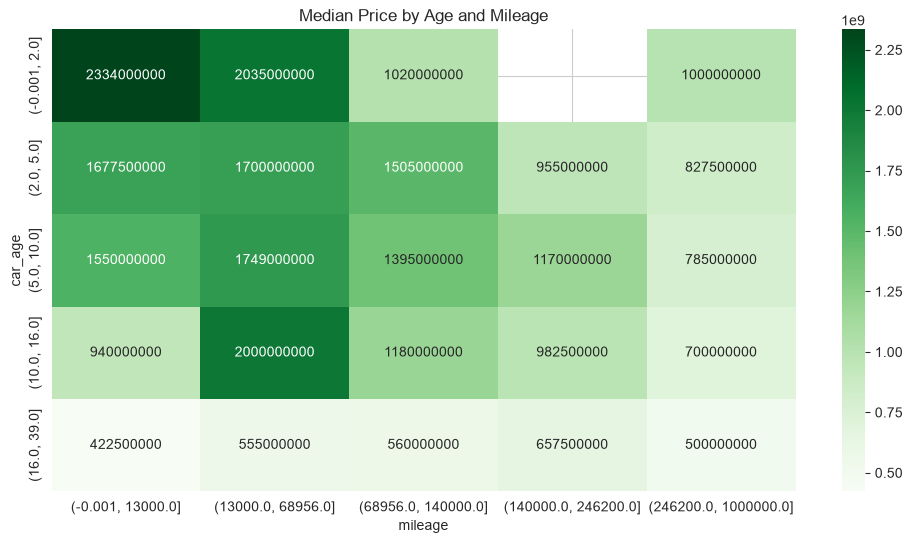

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='Greens'
)
plt.title('Median Price by Age and Mileage')
plt.show()

In [ ]:
pivot_count = pd.pivot_table(df, values='price', index=pd.qcut(df['car_age'],5), columns=pd.qcut(df['mileage'],5), aggfunc='count')
pivot_count

mileage,"(-0.001, 13000.0]","(13000.0, 68956.0]","(68956.0, 140000.0]","(140000.0, 246200.0]","(246200.0, 1000000.0]"
car_age,,,,,
"(-0.001, 2.0]",873.0000,314.0000,9.0000,NaN,1.0000
"(2.0, 5.0]",54.0000,485.0000,285.0000,17.0000,4.0000
"(5.0, 10.0]",25.0000,157.0000,526.0000,353.0000,53.0000
"(10.0, 16.0]",31.0000,23.0000,146.0000,408.0000,343.0000
"(16.0, 39.0]",22.0000,14.0000,52.0000,202.0000,598.0000


In [ ]:
for age_group in pivot.index:

    first = pivot.loc[age_group].iloc[0]
    last = pivot.loc[age_group].iloc[-1]

    decline = (first - last) / first * 100

    print(
        f"{age_group}: {decline:.1f}%"
    )

(-0.001, 2.0]: 57.2%
(2.0, 5.0]: 50.7%
(5.0, 10.0]: 49.4%
(10.0, 16.0]: 25.5%
(16.0, 39.0]: -18.3%


<Axes: xlabel='car_age', ylabel='price'>

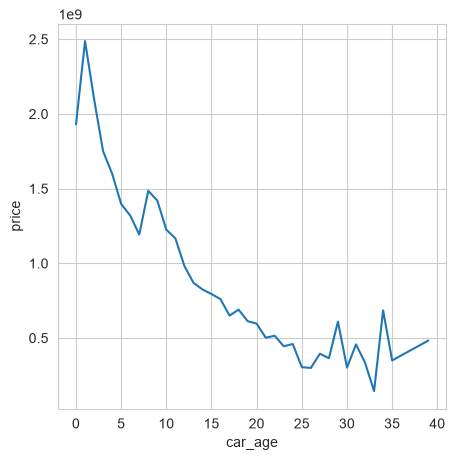

In [ ]:
age_price = (
    df.groupby('car_age')['price']
      .median()
      .reset_index()
)
plt.figure(figsize=(5,5))
sns.lineplot(
    data=age_price,
    x='car_age',
    y='price'
)

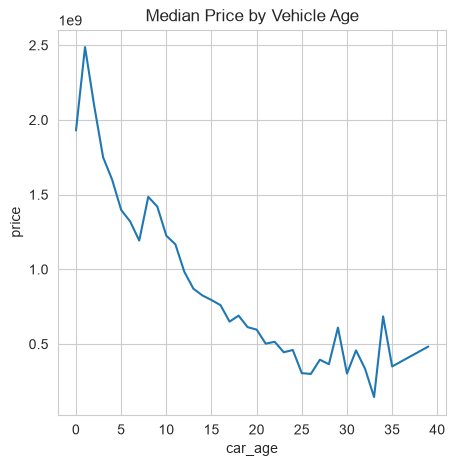

In [ ]:
age_price = (
    df.groupby('car_age')['price']
      .median()
      .reset_index()
)

plt.figure(figsize=(5,5))

sns.lineplot(
    data=age_price,
    x='car_age',
    y='price'
)

plt.title('Median Price by Vehicle Age')
plt.show()

In [ ]:
body_price = (
    df.groupby('score_body')['price']
      .agg(
          count='count',
          median='median'
      )
      .sort_values('median', ascending=False)
)
body_price

,count,median
score_body,,
Scrapped,3,5300000000.0000
Repainted in 6 area(s),3,3950000000.0000
"Healthy, No Scratches",2977,1700000000.0000
"Bodywork, No Paint",63,990000000.0000
Repainted in 1 area(s),315,970000000.0000
Minor Scratches,813,900000000.0000
Repainted in 2 area(s),203,870000000.0000
Repainted in 5 area(s),12,867500000.0000
Repainted in 4 area(s),41,790000000.0000
